# Taller de Aprendizaje No Supervisado
## Parte 1: Dataset de Setas (variables categóricas)

### Mushroom Dataset

Podéis obtener el conjunto de datos en el siguiente enlace:

[Mushroom Dataset](https://www.kaggle.com/uciml/mushroom-classification)

Como podréis comprobar, hay **muchas variables, todas categóricas**, por lo que las exploraciones con *scatterplot* no nos serán útiles como en otros casos.

La variable a predecir es `class` (`e` = comestible / *edible*, `p` = venenosa / *poisonous*) y es **binaria**.

> En este taller usaremos las etiquetas **solo para validar** lo que descubre el clustering. La idea del aprendizaje no supervisado es encontrar estructura *sin* mirar la etiqueta.

### Algoritmos que cubriremos

**Reducción de dimensionalidad:** PCA (lineal) y t-SNE (no lineal).

**Clustering:** K-Means, Clustering Jerárquico (Aglomerativo), Gaussian Mixture Models (GMM) y DBSCAN.

**Evaluación:** método del codo, *silhouette*, Davies-Bouldin, Calinski-Harabasz y (como tenemos etiqueta) Adjusted Rand Index y NMI.

**Detección de anomalías:** Isolation Forest.

In [2]:
# Carga de librerias, las que hemos considerado basicas, anadid lo que querais :)
%matplotlib inline
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
# Librerías añadidas
from sklearn.manifold import TSNE
from sklearn.cluster import AgglomerativeClustering, DBSCAN
from sklearn.mixture import GaussianMixture
from sklearn.ensemble import RandomForestClassifier, IsolationForest
# Métricas
from sklearn.metrics import silhouette_score, davies_bouldin_score, calinski_harabasz_score, adjusted_rand_score, normalized_mutual_info_score, f1_score, accuracy_score, precision_score, recall_score
from scipy.cluster.hierarchy import dendrogram, linkage

sns.set_theme(style='whitegrid')
RANDOM_STATE = 42

### Leer conjunto de datos y primer vistazo

In [3]:
# Leer el csv (esta en 'data/mushrooms.csv') y sacar por pantalla las cinco primeras filas.
df = pd.read_csv('data/mushrooms.csv')
df.head(5)

,class,cap-shape,cap-surface,cap-color,bruises,odor,gill-attachment,gill-spacing,gill-size,gill-color,...,stalk-surface-below-ring,stalk-color-above-ring,stalk-color-below-ring,veil-type,veil-color,ring-number,ring-type,spore-print-color,population,habitat
0,p,x,s,n,t,p,f,c,n,k,...,s,w,w,p,w,o,p,k,s,u
1,e,x,s,y,t,a,f,c,b,k,...,s,w,w,p,w,o,p,n,n,g
2,e,b,s,w,t,l,f,c,b,n,...,s,w,w,p,w,o,p,n,n,m
3,p,x,y,w,t,p,f,c,n,n,...,s,w,w,p,w,o,p,k,s,u
4,e,x,s,g,f,n,f,w,b,k,...,s,w,w,p,w,o,e,n,a,g


### Exploración de datos

In [4]:
# Descripcion del conjunto de datos, estandar.
df.describe()

,class,cap-shape,cap-surface,cap-color,bruises,odor,gill-attachment,gill-spacing,gill-size,gill-color,...,stalk-surface-below-ring,stalk-color-above-ring,stalk-color-below-ring,veil-type,veil-color,ring-number,ring-type,spore-print-color,population,habitat
count,8124,8124,8124,8124,8124,8124,8124,8124,8124,8124,...,8124,8124,8124,8124,8124,8124,8124,8124,8124,8124
unique,2,6,4,10,2,9,2,2,2,12,...,4,9,9,1,4,3,5,9,6,7
top,e,x,y,n,f,n,f,c,b,b,...,s,w,w,p,w,o,p,w,v,d
freq,4208,3656,3244,2284,4748,3528,7914,6812,5612,1728,...,4936,4464,4384,8124,7924,7488,3968,2388,4040,3148


In [5]:
# Informacion sobre el tipo de datos de cada feature.
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8124 entries, 0 to 8123
Data columns (total 23 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   class                     8124 non-null   object
 1   cap-shape                 8124 non-null   object
 2   cap-surface               8124 non-null   object
 3   cap-color                 8124 non-null   object
 4   bruises                   8124 non-null   object
 5   odor                      8124 non-null   object
 6   gill-attachment           8124 non-null   object
 7   gill-spacing              8124 non-null   object
 8   gill-size                 8124 non-null   object
 9   gill-color                8124 non-null   object
 10  stalk-shape               8124 non-null   object
 11  stalk-root                8124 non-null   object
 12  stalk-surface-above-ring  8124 non-null   object
 13  stalk-surface-below-ring  8124 non-null   object
 14  stalk-color-above-ring  

#### Calcular el número de nulos de cada feature

In [6]:
# Igual que otras veces, una linea: contar los nulos por variable.
df.isnull().sum()

class                       0
cap-shape                   0
cap-surface                 0
cap-color                   0
bruises                     0
odor                        0
gill-attachment             0
gill-spacing                0
gill-size                   0
gill-color                  0
stalk-shape                 0
stalk-root                  0
stalk-surface-above-ring    0
stalk-surface-below-ring    0
stalk-color-above-ring      0
stalk-color-below-ring      0
veil-type                   0
veil-color                  0
ring-number                 0
ring-type                   0
spore-print-color           0
population                  0
habitat                     0
dtype: int64

#### Buscar valores extraños. Para ello, ver los valores únicos en cada feature

In [7]:
# Obtener un nuevo dataframe: en una columna las features (feature)
# y en la otra el numero de valores unicos asociados (n_values).
n_values = df.nunique().reset_index()
n_values.columns = ['feature', 'n_values']
n_values

,feature,n_values
0,class,2
1,cap-shape,6
2,cap-surface,4
3,cap-color,10
4,bruises,2
5,odor,9
6,gill-attachment,2
7,gill-spacing,2
8,gill-size,2
9,gill-color,12


Observad dos cosas:
- `veil-type` tiene **un único valor** → no aporta información.
- `stalk-root` contiene el valor `'?'`, que en realidad es un **valor desconocido (nulo encubierto)**.

#### Tratar aquellos valores que entendamos que sean nulos

In [8]:
# Imputaciones. Podeis quitar esos puntos (fila entera), imputar con la moda
# o dejar ese valor como una posibilidad mas. Aqui imputamos '?' con la moda.
moda_stalk = df['stalk-root'].replace('?', np.nan).mode()[0]
df['stalk-root'] = df['stalk-root'].replace('?', moda_stalk)

#### ¿Todas las features aportan información? Si alguna no aporta, eliminadla

In [9]:
# Dejar por el camino las features con un solo valor (no aportan nada).
df.drop(columns=['veil-type'], inplace=True, errors='ignore')

#### Separar entre variables predictoras y variable a predecir

In [10]:
# La variable a predecir es 'class'.
y = df['class']
X = df.drop(columns=['class'])

#### Codificar correctamente las variables categóricas a numéricas

In [11]:
# One Hot Encoder (una linea). Pista: pd.get_dummies
x = pd.get_dummies(X, drop_first=True)

#### Train / test split

In [12]:
# Os lo dejamos a todos igual
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.33, random_state=42)

## PCA

Es un conjunto de datos del que aún no hemos visto gráficas, así que vamos a hacer algunas. Tenemos muchas variables, **PCA al rescate**: le pedimos dos dimensiones y las pintamos. Serán **las que retengan más información (varianza)**.

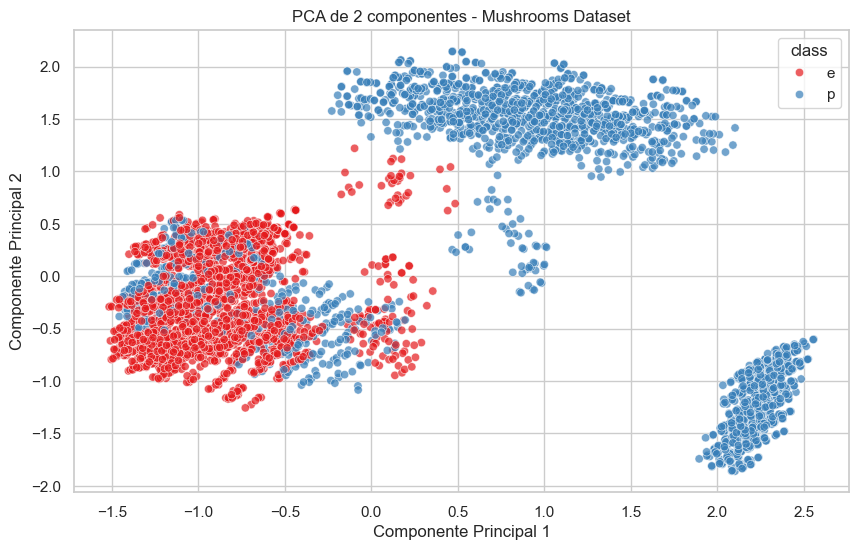

In [13]:
# Ajustar PCA de 2 componentes
pca = PCA(n_components=2, random_state=RANDOM_STATE)      # metodo de sklearn
x_train_pca = pca.fit_transform(x_train)

# Representar en un scatterplot y poner en color las etiquetas de entrenamiento
plt.figure(figsize=(10, 6))
sns.scatterplot(x=x_train_pca[:, 0], y=x_train_pca[:, 1], hue=y_train, palette='Set1', alpha=0.7)
plt.title('PCA de 2 componentes - Mushrooms Dataset')
plt.xlabel('Componente Principal 1')
plt.ylabel('Componente Principal 2')
plt.show()

Parece que está bastante separadito, ¡a ojo mucho se puede ver! :)

Antes de seguir, entrenamos un clasificador supervisado como **línea base** (así sabemos cuánta información hay realmente en los datos).

In [14]:
# 1. Definir el clasificador y el numero de estimadores
rf = RandomForestClassifier(n_estimators=100, random_state=RANDOM_STATE)
# 2. Entrenar en train
rf.fit(x_train, y_train)
# 3. Calcular la precision sobre test
y_pred = rf.predict(x_test)
print(f"Accuracy de la línea base: {accuracy_score(y_test, y_pred):.4f}")

Accuracy de la línea base: 1.0000


Es un conjunto sencillo y Random Forest es muy bueno. Veamos cuántas features tenemos:

In [16]:
x_train.shape

(5443, 94)

¿Muchas features, no? Vamos a reducirlas con PCA y ver cuántas componentes necesita Random Forest para mantener su precisión.

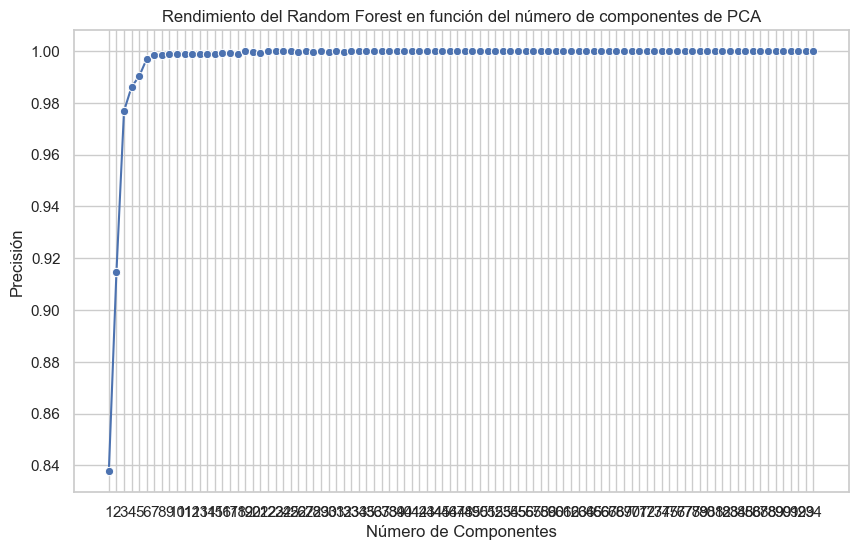

In [19]:
n_features = range(1, x_train.shape[1] + 1)  # definir un rango de valores a probar
scores = []

for n in n_features:
    # 1. Definir y ajustar PCA sobre X_train
    pca_temp = PCA(n_components=n, random_state=RANDOM_STATE)
    x_train_red = pca_temp.fit_transform(x_train)
    x_test_red = pca_temp.transform(x_test)
    # 2. Entrenar Random Forest sobre los datos reducidos
    rf_temp = RandomForestClassifier(n_estimators=100, random_state=RANDOM_STATE)
    rf_temp.fit(x_train_red, y_train)
    # 3. Guardar el score en test
    scores.append(rf_temp.score(x_test_red, y_test))

# Hacer gráfico de curva de rendimiento
plt.figure(figsize=(10, 6))
sns.lineplot(x=list(n_features), y=scores, marker='o')
plt.title('Rendimiento del Random Forest en función del número de componentes de PCA')
plt.xlabel('Número de Componentes')
plt.ylabel('Precisión')
plt.xticks(list(n_features))
plt.show()

A partir de ~10 componentes ya tenemos la precisión que queríamos, reduciendo las variables a una fracción de las originales.

---
## t-SNE: reducción **no lineal** para visualizar

PCA es lineal. **t-SNE** intenta preservar la vecindad local y suele separar mejor los grupos visualmente. Es más caro, así que lo calculamos sobre una **muestra**.

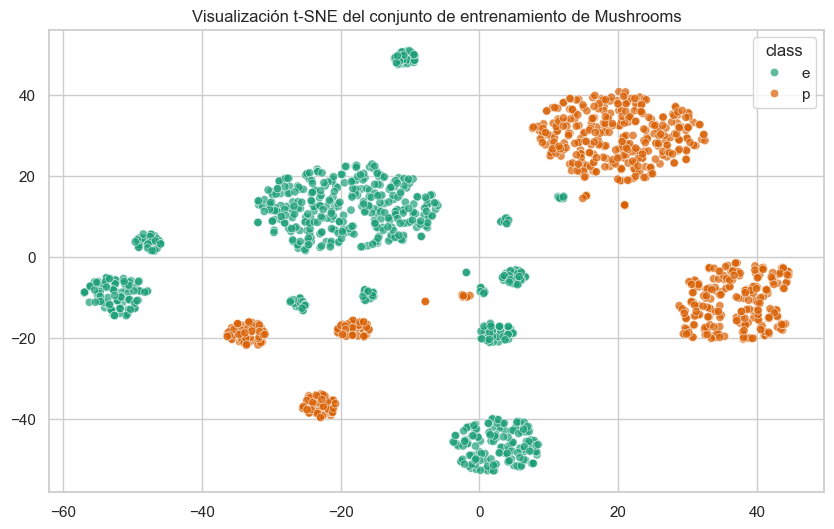

In [21]:
# 1. Tomar una muestra de X_train (t-SNE es lento)
x_sample, _, y_sample, _ = train_test_split(x_train, y_train, train_size=1500, random_state=RANDOM_STATE,stratify=y_train)
# 2. Definir TSNE(n_components=2, ...) y ajustar
tsne = TSNE(n_components=2, random_state=RANDOM_STATE, perplexity=30, max_iter=1000)
x_sample_tsne = tsne.fit_transform(x_sample)
# 3. Pintar el embedding coloreado por la etiqueta
plt.figure(figsize=(10, 6))
sns.scatterplot(x=x_sample_tsne[:, 0], y=x_sample_tsne[:, 1], hue=y_sample, palette='Dark2', alpha=0.7)
plt.title('Visualización t-SNE del conjunto de entrenamiento de Mushrooms')
plt.show()

---
## Clustering

El conjunto es sencillito, así que probemos clustering para ver qué información obtenemos **sin usar las etiquetas**. Trabajaremos sobre una representación reducida con PCA (10 componentes), que limpia ruido y acelera los algoritmos.

In [22]:
# Reducir X (one-hot completo) a 10 componentes con PCA -> X_red
pca_10 =PCA(n_components=10, random_state=RANDOM_STATE)
x_red = pca_10.fit_transform(x)

### K-Means: ¿cuántos clusters? Codo + Silhouette

El **método del codo** mira la inercia (suma de distancias a los centroides). El **coeficiente de silhouette** mide cómo de bien separados están los clusters (cuanto más alto, mejor). Usamos ambos.

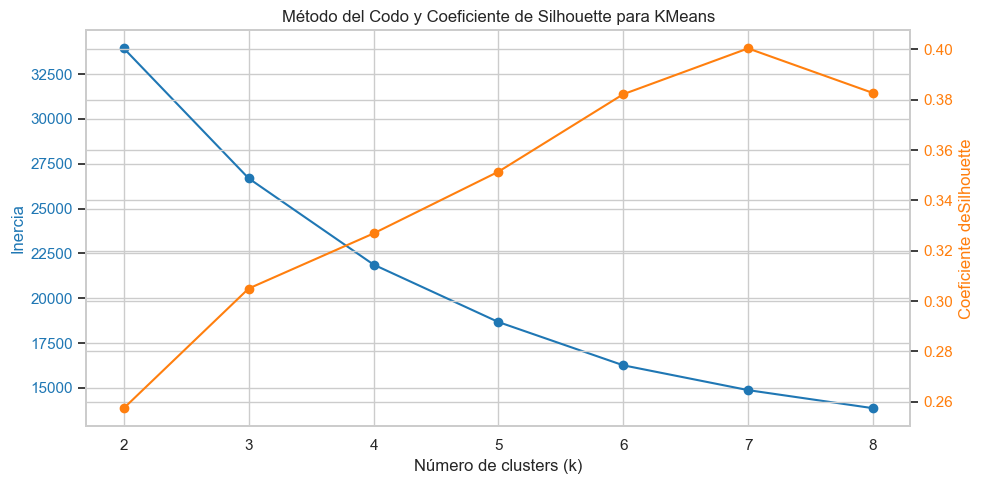

In [23]:
# from sklearn.cluster import KMeans
k_values = range(2, 9)  # definir un rango
inercias, silhouettes = [], []
for k in k_values:
    # Definir KMeans y ajustar sobre X_red
    km = KMeans(n_clusters=k, random_state=RANDOM_STATE, n_init=10)
    labels = km.fit_predict(x_red)
    # Guardar la inercia (km.inertia_) y el silhouette_score
    inercias.append(km.inertia_)
    silhouettes.append(silhouette_score(x_red, labels))

# Pintar las dos curvas (codo y silhouette)
fig, ax1 = plt.subplots(figsize=(10, 5))

color = 'tab:blue'
ax1.set_xlabel('Número de clusters (k)')
ax1.set_ylabel('Inercia', color=color)
ax1.plot(k_values, inercias, marker='o', color=color)
ax1.tick_params(axis='y', labelcolor=color)

ax2 = ax1.twinx()  # Instancia un segundo eje que comparte el mismo eje x
color = 'tab:orange'
ax2.set_ylabel('Coeficiente deSilhouette', color=color)
ax2.plot(k_values, silhouettes, marker='o', color=color)
ax2.tick_params(axis='y', labelcolor=color)

plt.title('Método del Codo y Coeficiente de Silhouette para KMeans')
fig.tight_layout()
plt.show()

### K-Means final y comparación con la etiqueta

Sabemos que hay dos clases (comestible / venenosa), así que probamos `k=2`. Con `catplot` vemos la distribución de la etiqueta real dentro de cada cluster.

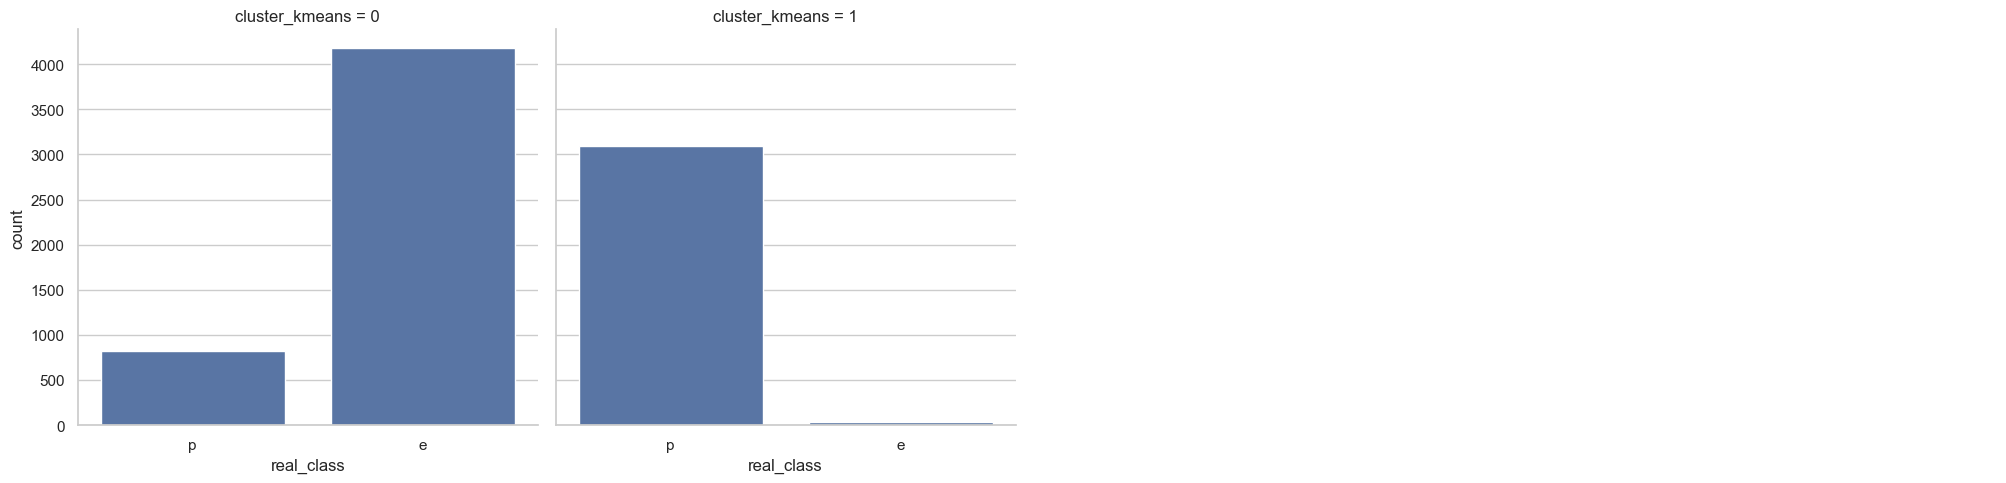

K-Means (k=2) -> ARI: 0.6233, NMI: 0.5824


In [24]:
# Aprender KMeans con el k obtenido y preparar el catplot.
kmeans = KMeans(n_clusters=2, random_state=RANDOM_STATE, n_init=10)  # Definir y entrenar KMeans
df['cluster_kmeans'] = kmeans.fit_predict(x_red)

df['real_class'] = y # Convertir la variable y a binaria

# Preparar el catplot
ax = sns.catplot(col='cluster_kmeans', x='real_class', data=df, kind='count', col_wrap=4)
plt.show()
# Calcular ARI y NMI frente a y_bin
ari_km = adjusted_rand_score(df['real_class'], df['cluster_kmeans'])
nmi_km = normalized_mutual_info_score(df['real_class'], df['cluster_kmeans'])

print(f"K-Means (k=2) -> ARI: {ari_km:.4f}, NMI: {nmi_km:.4f}")

> **ARI / NMI** comparan los clusters con la etiqueta real (0 = aleatorio, 1 = idéntico). Sin haber visto la etiqueta, K-Means recupera buena parte de la estructura comestible/venenosa, pero **no es perfecto**: ese es el reto real del no supervisado.

### Comparativa de algoritmos de clustering

Vamos a poner a competir **K-Means, Aglomerativo, GMM y DBSCAN** con varias métricas. Las tres primeras métricas son *internas* (no usan etiqueta); ARI sí la usa, para validar.

In [26]:
# Definir una funcion evaluar(nombre, labels, X) que devuelva silhouette,
# davies_bouldin, calinski_harabasz y ARI.
# Aplicarla a KMeans, AgglomerativeClustering, GaussianMixture y DBSCAN
# y montar una tabla (DataFrame) comparativa.

def evaluar(nombre, labels, x_data, y_true):
    if len(set(labels)) - (1 if -1 in labels else 0) < 2:
        return {'Algoritmo': nombre, 'Silhouette': np.nan, 'Davies-Bouldin': np.nan, 'Calinski-Harabasz': np.nan, 'ARI': np.nan}
    
    sil = silhouette_score(x_data, labels)
    db = davies_bouldin_score(x_data, labels)
    ch = calinski_harabasz_score(x_data, labels)
    ari = adjusted_rand_score(y_true, labels)

    return {
        'Algoritmo': nombre, 
        'Silhouette': round(sil, 4), 
        'Davies-Bouldin': round(db, 4), 
        'Calinski-Harabasz': round(ch, 4), 
        'ARI': round(ari, 4)}

# Instanciar modelos
res_km = evaluar('KMeans (k=2)', KMeans(n_clusters=2, random_state=RANDOM_STATE, n_init=10).fit_predict(x_red), x_red, y)
res_agg = evaluar('Agglomerative (k=2)', AgglomerativeClustering(n_clusters=2).fit_predict(x_red), x_red, y)
res_gmm = evaluar('Gaussian Mixture (k=2)', GaussianMixture(n_components=2, random_state=RANDOM_STATE).fit_predict(x_red), x_red, y)
res_db = evaluar('DBSCAN (Euclidean)', DBSCAN(eps=1.5, min_samples=5).fit_predict(x_red), x_red, y)

# Crear DataFrame comparativo
df_comparativo = pd.DataFrame([res_km, res_agg, res_gmm, res_db])
df_comparativo

,Algoritmo,Silhouette,Davies-Bouldin,Calinski-Harabasz,ARI
0,KMeans (k=2),0.2574,1.6537,2711.0248,0.6233
1,Agglomerative (k=2),0.2542,1.6626,2641.2045,0.6090
2,Gaussian Mixture (k=2),0.2535,1.6655,2637.6264,0.6032
3,DBSCAN (Euclidean),0.2191,1.0635,1386.5255,0.1093


### Dendrograma (clustering jerárquico)

El clustering aglomerativo construye una jerarquía que podemos visualizar como **dendrograma**. La altura a la que se unen dos grupos indica cómo de distintos son. Lo calculamos sobre una muestra para que se lea bien.

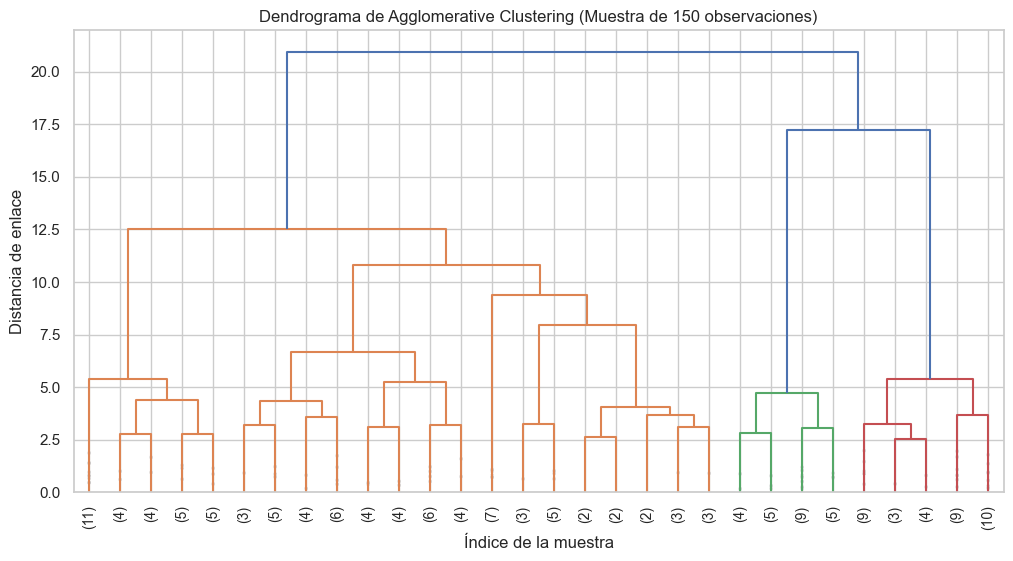

In [27]:
# 1. Tomar una muestra de X_red
x_sample_dendro, _, _, _ = train_test_split(x_red, y, train_size=150, random_state=RANDOM_STATE, stratify=y)
# 2. linkage(..., method='ward')
z = linkage(x_sample_dendro, method='ward')
# 3. dendrogram(...) para visualizar la jerarquia
plt.figure(figsize=(12, 6))
dendrogram(z, truncate_mode='lastp', p=30, leaf_rotation=90., leaf_font_size=10., show_contracted=True)
plt.title('Dendrograma de Agglomerative Clustering (Muestra de 150 observaciones)')
plt.xlabel('Índice de la muestra')
plt.ylabel('Distancia de enlace')
plt.show()

### DBSCAN: la **métrica de distancia importa**

DBSCAN agrupa por densidad. Pero con datos **categóricos** codificados en one-hot, la distancia euclídea no captura bien la similitud. Comparemos euclídea (sobre PCA) con la distancia de **Jaccard** (pensada para datos binarios).

In [29]:
# Comparar DBSCAN con metric='euclidean' (sobre X_red) y metric='jaccard'
# (sobre el one-hot binario). Observar cual recupera mejor la estructura (ARI).

# DBSCAN con métrica euclidiana sobre X_red
db_euclidean = DBSCAN(eps=1.8, min_samples=10)
labels_euclidean = db_euclidean.fit_predict(x_red)
ari_euclidean = adjusted_rand_score(y, labels_euclidean)

# DBSCAN con métrica jaccard sobre el one-hot binario
db_jaccard = DBSCAN(eps=0.3, min_samples=10, metric='jaccard')
labels_jaccard = db_jaccard.fit_predict(x)
ari_jaccard = adjusted_rand_score(y, labels_jaccard)

print(f"Resultados de validación externa (ARI):")
print(f"DBSCAN (Euclidean): {ari_euclidean:.4f}")
print(f"DBSCAN (Jaccard): {ari_jaccard:.4f}")

Resultados de validación externa (ARI):
DBSCAN (Euclidean): 0.1093
DBSCAN (Jaccard): 0.3237


> **Lección:** con datos categóricos, elegir la distancia adecuada (Jaccard/Hamming) puede cambiar por completo el resultado de un algoritmo basado en densidad. No hay un algoritmo que gane siempre: depende del tipo de datos.

### Visualización final: clusters vs etiqueta real

Repetimos el scatter PCA, pero coloreando por el cluster de K-Means y por la etiqueta real, lado a lado.

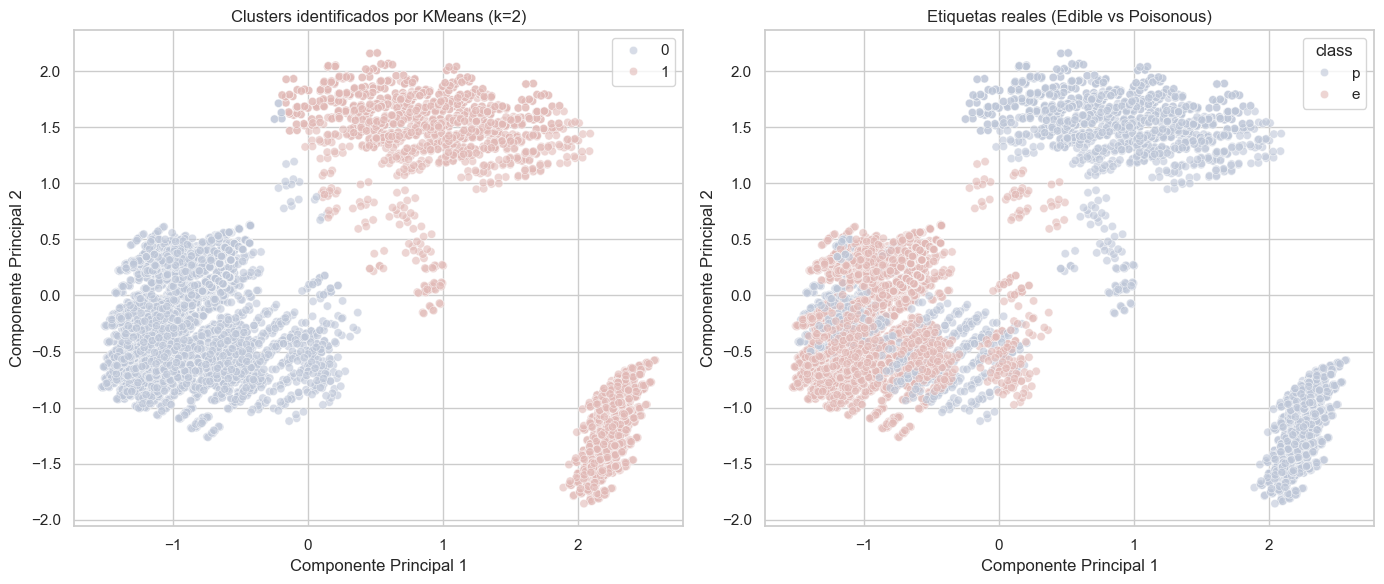

In [30]:
# Entrenar PCA(2) sobre X para representar.
pca_2d = PCA(n_components=2, random_state=RANDOM_STATE)
x_vis = pca_2d.fit_transform(x)

labels_km_final = KMeans(n_clusters=2, random_state=RANDOM_STATE, n_init=10).fit_predict(x_red)

# Pintar dos scatter: uno coloreado por el cluster de KMeans y otro por la etiqueta real.
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
# Scatter coloreado por clusters identificados por KMeans
sns.scatterplot(x=x_vis[:, 0], y=x_vis[:, 1], hue=labels_km_final, palette='vlag', alpha=0.6, ax=axes[0])
axes[0].set_title('Clusters identificados por KMeans (k=2)')
axes[0].set_xlabel('Componente Principal 1')
axes[0].set_ylabel('Componente Principal 2')

# Scatter coloreado por etiquetas reales
sns.scatterplot(x=x_vis[:, 0], y=x_vis[:, 1], hue=y, palette='vlag', alpha=0.6, ax=axes[1])
axes[1].set_title('Etiquetas reales (Edible vs Poisonous)')
axes[1].set_xlabel('Componente Principal 1')
axes[1].set_ylabel('Componente Principal 2')

plt.tight_layout()
plt.show()

Es bastante parecido, ¿no? No es tan bueno como Random Forest (que usa etiquetas), pero K-Means ha identificado bastante bien la estructura **sin usarlas**. Si no tuviéramos etiquetas, esta aproximación nos ayudaría mucho a clasificar los tipos de hongos.

---
## Detección de anomalías (Isolation Forest)

Una tarea no supervisada distinta: encontrar las muestras **atípicas**. Isolation Forest aísla los puntos raros con pocos cortes aleatorios.

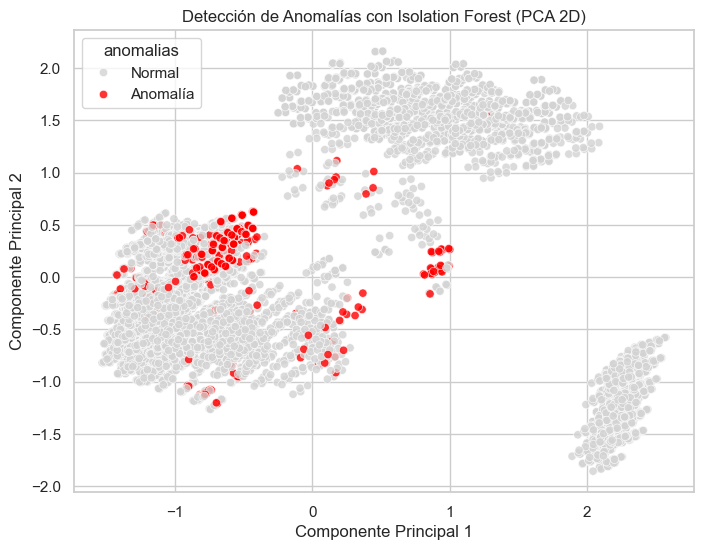

In [32]:
# 1. Definir IsolationForest(contamination=...) y ajustar sobre X_red
iso_forest = IsolationForest(contamination=0.05, random_state=RANDOM_STATE)
anomalias = iso_forest.fit_predict(x_red)

# 2. predict -> -1 son anomalias
df['anomalias'] = np.where(anomalias == -1, 'Anomalía', 'Normal')

# 3. Pintarlas sobre la proyeccion PCA
plt.figure(figsize=(8, 6))
sns.scatterplot(x=x_vis[:, 0], y=x_vis[:, 1], hue=df['anomalias'], palette={'Normal': 'lightgray', 'Anomalía': 'red'}, alpha=0.8)
plt.title('Detección de Anomalías con Isolation Forest (PCA 2D)')
plt.xlabel('Componente Principal 1')
plt.ylabel('Componente Principal 2')
plt.show()

---
## Para ir más allá (opcional)

- **UMAP** (`pip install umap-learn`): alternativa a t-SNE, más rápida y preserva mejor la estructura global.
- **HDBSCAN** (`pip install hdbscan`): DBSCAN jerárquico que no necesita fijar `eps`.
- **Reglas de asociación** (`mlxtend`, Apriori/FP-Growth): muy naturales aquí por ser datos categóricos; permiten descubrir reglas tipo «si olor = X entonces venenosa».

## Conclusiones

- PCA y t-SNE nos dejaron *ver* un dataset de >100 dimensiones.
- K-Means, GMM y Aglomerativo recuperan la estructura comestible/venenosa con ARI ~0.6 **sin usar la etiqueta**.
- DBSCAN nos enseñó que **la métrica de distancia importa** con datos categóricos.
- Isolation Forest localiza las setas más atípicas.
- El no supervisado no da una respuesta «perfecta», pero descubre estructura muy útil cuando no tenemos etiquetas.